In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
data = pd.read_csv(
    "../datasets/processed/day14_financial_ratios_dataset.csv"
)

print("Dataset loaded successfully!")
print("Shape:", data.shape)
print(data.head())

Dataset loaded successfully!
Shape: (110, 19)
  company ticker  year  year_end_price  dividend_per_share  dividend_yield  \
0   Apple   AAPL  2015       26.315001              0.5075            1.93   
1   Apple   AAPL  2016       28.955000              0.5575            1.93   
2   Apple   AAPL  2017       42.307499              0.6150            1.45   
3   Apple   AAPL  2018       39.435001              0.7050            1.79   
4   Apple   AAPL  2019       73.412498              0.7600            1.04   

   dividend_growth dividend_growth_category  annual_stock_return  \
0              NaN               First Year                  NaN   
1             9.85                Increased                10.03   
2            10.31                Increased                46.11   
3            14.63                Increased                -6.79   
4             7.80                Increased                86.16   

  return_category  total_return  return_volatility  average_return  \
0     

In [3]:
required_columns = [
    "ticker",
    "year",
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "return_volatility",
    "total_return"
]

for col in required_columns:
    print(col, "->", col in data.columns)

ticker -> True
year -> True
dividend_yield -> True
dividend_growth -> True
dividend_consistency -> True
return_volatility -> True
total_return -> True


In [4]:
bird_data = data[
    [
        "ticker",
        "year",
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "return_volatility",
        "total_return"
    ]
].copy()

print("Bird-in-Hand dataset shape:", bird_data.shape)
print(bird_data.head())

Bird-in-Hand dataset shape: (110, 7)
  ticker  year  dividend_yield  dividend_growth  dividend_consistency  \
0   AAPL  2015            1.93              NaN                 90.91   
1   AAPL  2016            1.93             9.85                 90.91   
2   AAPL  2017            1.45            10.31                 90.91   
3   AAPL  2018            1.79            14.63                 90.91   
4   AAPL  2019            1.04             7.80                 90.91   

   return_volatility  total_return  
0              36.16           NaN  
1              36.16         11.96  
2              36.16         47.56  
3              36.16         -5.00  
4              36.16         87.20  


In [5]:
print("Missing values:")
print(bird_data.isnull().sum())

Missing values:
ticker                   0
year                     0
dividend_yield           0
dividend_growth         10
dividend_consistency     0
return_volatility        0
total_return            10
dtype: int64


In [6]:
analysis_data = bird_data.dropna(
    subset=[
        "dividend_yield",
        "dividend_growth",
        "dividend_consistency",
        "return_volatility",
        "total_return"
    ]
).copy()

print("Complete analysis rows:", analysis_data.shape)

Complete analysis rows: (100, 7)


In [7]:
correlation_columns = [
    "dividend_yield",
    "dividend_growth",
    "dividend_consistency",
    "return_volatility",
    "total_return"
]

correlation_matrix = analysis_data[
    correlation_columns
].corr()

print(correlation_matrix.round(4))

                      dividend_yield  dividend_growth  dividend_consistency  \
dividend_yield                1.0000          -0.4839                   NaN   
dividend_growth              -0.4839           1.0000                   NaN   
dividend_consistency             NaN              NaN                   NaN   
return_volatility            -0.3027           0.1365                   NaN   
total_return                 -0.4089           0.1139                   NaN   

                      return_volatility  total_return  
dividend_yield                  -0.3027       -0.4089  
dividend_growth                  0.1365        0.1139  
dividend_consistency                NaN           NaN  
return_volatility                1.0000        0.3127  
total_return                     0.3127        1.0000  


In [8]:
yield_return_corr = analysis_data[
    ["dividend_yield", "total_return"]
].corr().iloc[0, 1]

yield_volatility_corr = analysis_data[
    ["dividend_yield", "return_volatility"]
].corr().iloc[0, 1]

consistency_return_corr = analysis_data[
    ["dividend_consistency", "total_return"]
].corr().iloc[0, 1]

consistency_volatility_corr = analysis_data[
    ["dividend_consistency", "return_volatility"]
].corr().iloc[0, 1]

growth_return_corr = analysis_data[
    ["dividend_growth", "total_return"]
].corr().iloc[0, 1]

growth_volatility_corr = analysis_data[
    ["dividend_growth", "return_volatility"]
].corr().iloc[0, 1]

print("Dividend Yield vs Total Return:",
      round(yield_return_corr, 4))

print("Dividend Yield vs Return Volatility:",
      round(yield_volatility_corr, 4))

print("Dividend Consistency vs Total Return:",
      round(consistency_return_corr, 4))

print("Dividend Consistency vs Return Volatility:",
      round(consistency_volatility_corr, 4))

print("Dividend Growth vs Total Return:",
      round(growth_return_corr, 4))

print("Dividend Growth vs Return Volatility:",
      round(growth_volatility_corr, 4))

Dividend Yield vs Total Return: -0.4089
Dividend Yield vs Return Volatility: -0.3027
Dividend Consistency vs Total Return: nan
Dividend Consistency vs Return Volatility: nan
Dividend Growth vs Total Return: 0.1139
Dividend Growth vs Return Volatility: 0.1365


In [9]:
bird_results = pd.DataFrame({
    "Relationship": [
        "Dividend Yield vs Total Return",
        "Dividend Yield vs Return Volatility",
        "Dividend Consistency vs Total Return",
        "Dividend Consistency vs Return Volatility",
        "Dividend Growth vs Total Return",
        "Dividend Growth vs Return Volatility"
    ],
    "Correlation": [
        yield_return_corr,
        yield_volatility_corr,
        consistency_return_corr,
        consistency_volatility_corr,
        growth_return_corr,
        growth_volatility_corr
    ]
})

bird_results["Absolute_Correlation"] = (
    bird_results["Correlation"].abs()
)

print(bird_results.round(4))

                                Relationship  Correlation  \
0             Dividend Yield vs Total Return      -0.4089   
1        Dividend Yield vs Return Volatility      -0.3027   
2       Dividend Consistency vs Total Return          NaN   
3  Dividend Consistency vs Return Volatility          NaN   
4            Dividend Growth vs Total Return       0.1139   
5       Dividend Growth vs Return Volatility       0.1365   

   Absolute_Correlation  
0                0.4089  
1                0.3027  
2                   NaN  
3                   NaN  
4                0.1139  
5                0.1365  


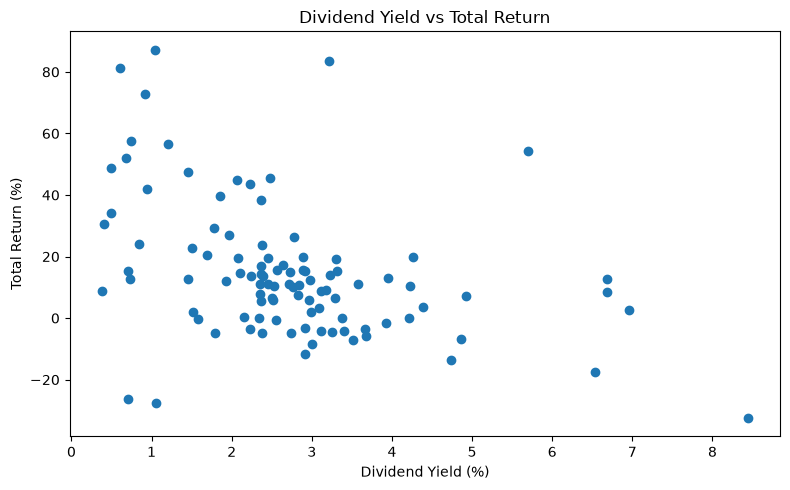

In [10]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["total_return"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Total Return (%)")
plt.title("Dividend Yield vs Total Return")

plt.tight_layout()
plt.show()

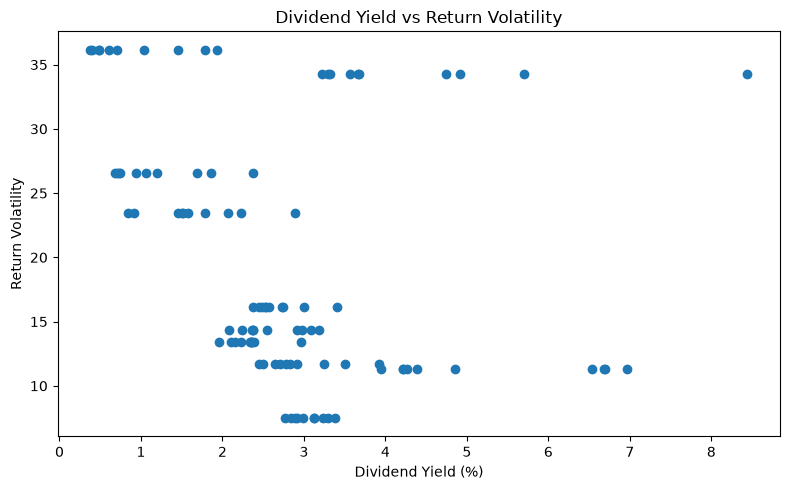

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_yield"],
    analysis_data["return_volatility"]
)

plt.xlabel("Dividend Yield (%)")
plt.ylabel("Return Volatility")
plt.title("Dividend Yield vs Return Volatility")

plt.tight_layout()
plt.show()

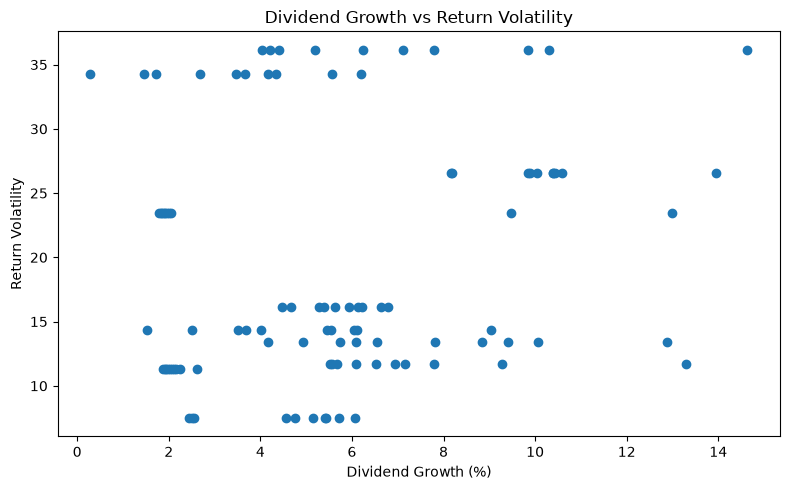

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["dividend_growth"],
    analysis_data["return_volatility"]
)

plt.xlabel("Dividend Growth (%)")
plt.ylabel("Return Volatility")
plt.title("Dividend Growth vs Return Volatility")

plt.tight_layout()
plt.show()

In [13]:
bird_results.to_csv(
    "../datasets/processed/day24_bird_in_hand_results.csv",
    index=False
)

print("Day 24 Bird-in-Hand results saved successfully!")

Day 24 Bird-in-Hand results saved successfully!


In [14]:
print(bird_results.round(4))

                                Relationship  Correlation  \
0             Dividend Yield vs Total Return      -0.4089   
1        Dividend Yield vs Return Volatility      -0.3027   
2       Dividend Consistency vs Total Return          NaN   
3  Dividend Consistency vs Return Volatility          NaN   
4            Dividend Growth vs Total Return       0.1139   
5       Dividend Growth vs Return Volatility       0.1365   

   Absolute_Correlation  
0                0.4089  
1                0.3027  
2                   NaN  
3                   NaN  
4                0.1139  
5                0.1365  
